# Test model

Loads the trained model from disk and evaluates it: backtests it on the held-out
test period and analyses its predictions on new (out-of-train) data.

In [ ]:
import ast
import json

import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


class CFG:
    # maximum number of simultaneously opened trades
    max_num_simult_trades = 100
    # TP / SL target ratios used to label the data (see target_high_ratio / target_low_ratio
    # in prepare_data.ipynb: 1.05 / 0.95 -> 0.05 / 0.05)
    TP = 0.05
    SL = 0.05
    slippage = 0.002
    test_time_days = 90

## Load the data

In [26]:
train_df = pd.read_pickle("data/train_df.pkl")

# all data for the last test_time_days are test
test_date = train_df["time"].max() - pd.to_timedelta(CFG.test_time_days, unit="D")

profitable_hours_df = pd.read_csv("data/profitable_hours.csv")
latest = profitable_hours_df.iloc[-1]
buy_hours = ast.literal_eval(latest["profitable_buy_hours"])
sell_hours = ast.literal_eval(latest["profitable_sell_hours"])

buy_mask = (train_df["ttype"] == "buy") & (train_df["time"].dt.hour.isin(buy_hours))
sell_mask = (train_df["ttype"] == "sell") & (train_df["time"].dt.hour.isin(sell_hours))
train_df = train_df[buy_mask | sell_mask].reset_index(drop=True)

## Load the trained model and parameters from disk

In [ ]:
model = joblib.load("model/lgbm.pkl")
# the model stores the exact feature set it was trained on
features = list(model.feature_name_)

with open("model/bybit_tickers.json", "r") as f:
    bybit_tickers = json.load(f)

# best prediction threshold found during optimization
# p > high_bound -> predicted positive (open a trade)
optuna_df = pd.read_csv("model/optuna/optuna_lgbm.csv")
high_bound = optuna_df["params_high_bound"].iloc[0]

## Backtest model

Backtest is run on the held-out **test** period (`time > test_date`) using predictions
from the model loaded from disk.

I don't consider funding fees because they can be both positive and negative. I can do it
because typical funding fee is positive and the majority of my trades are shorts, so I can
even earn on funding. But I think it's better not to consider it at all.

100%|██████████| 8935/8935 [00:00<00:00, 324583.67it/s]

Result balance increase is 206.0%


<Axes: title={'center': 'Trade balance vs Number of trades'}, xlabel='Number of trades', ylabel='Balance, %'>

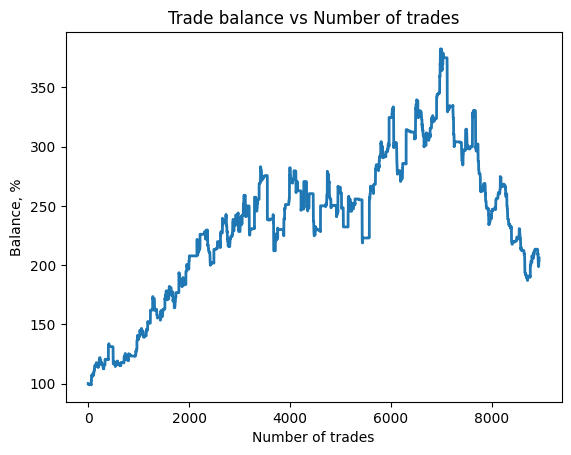

In [28]:
from utils.model_test_utils import backtest

# predict on the test period and backtest those predictions
test_mask = (train_df["ticker"].isin(bybit_tickers)) & (train_df["time"] > test_date)
test_idxs = train_df[test_mask].index
test_pred = model.predict_proba(train_df.loc[test_idxs, features])[:, 1]

result, backtest_df = backtest(
    train_df, 
    test_pred, 
    test_idxs, 
    high_bound, 
    tp=CFG.TP - CFG.slippage,
    sl=CFG.SL + CFG.slippage,
    show_progress=True, 
    max_num_simult_trades=CFG.max_num_simult_trades,
)

# plot the balance
backtest_plot = backtest_df["balance"].reset_index(drop=True)
backtest_plot = backtest_plot * 100

print(f"Result balance increase is {round(result, 3)}%")

plt.xlabel("Number of trades")
plt.ylabel("Balance, %")
plt.title("Trade balance vs Number of trades")
backtest_plot.plot(linewidth=2)

## Test model predictions on the new data

List of possible reasons of inconsistence between real and train predictions of tickers

- ticker price doesn't reach the TP or SL thresholds yet

- errors in the data preparation pipeline make model give different predictions

- bot was used in debug mode

- too small volume

- ticker is not presented in bybit_ticker_list due to errors

- ticker was added to exchange not too much time ago

- different high_bound threshold

- different time for prediction

- there are NaNs in the ticker dataframe

- signal was one of the last in the dataframe and was deleted due to signal error protection measures

In [29]:
from utils.model_test_utils import cap_max_num_simult_trades

X = train_df[(train_df["ticker"].isin(bybit_tickers))]
X["pred"] = model.predict_proba(X[features])[:,1]
res = X.loc[((X["pred"] >= high_bound)) & (X["time"] > test_date), ["time", "ticker", "ttype", "pred", "target", "pattern"]]
res = cap_max_num_simult_trades(res, CFG.max_num_simult_trades)
res = res.reset_index(drop=True)
display(res["time"].min(), res["time"].max())
display(res["target"].value_counts())
display(res["target"].value_counts(normalize=True))
display(res[["time", "ticker", "ttype", "pred", "target"]].tail(50))

/tmp/ipykernel_624102/1959248060.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["pred"] = model.predict_proba(X[features])[:,1]


Timestamp('2024-06-04 04:00:00')

Timestamp('2026-06-03 18:00:00')

target
1    5082
0    3853
Name: count, dtype: int64

target
1    0.568774
0    0.431226
Name: proportion, dtype: float64

,time,ticker,ttype,pred,target
8885,2026-05-28 11:00:00,AXSUSDT,buy,0.719643,0
8886,2026-05-28 11:00:00,AEVOUSDT,buy,0.719555,0
8887,2026-05-28 11:00:00,MEWUSDT,buy,0.550186,1
8888,2026-05-28 11:00:00,SOONUSDT,buy,0.606727,1
8889,2026-05-28 11:00:00,BNBUSDT,buy,0.743208,0
8890,2026-05-28 11:00:00,1000TURBOUSDT,buy,0.899245,0
8891,2026-05-28 11:00:00,NOTUSDT,buy,0.771464,0
8892,2026-05-28 11:00:00,AVAAIUSDT,buy,0.873889,0
8893,2026-05-28 11:00:00,OPUSDT,buy,0.662726,0
8894,2026-05-28 11:00:00,WIFUSDT,buy,0.570992,0


### Plot rolling mean precision score of the model predictions for the test data

/tmp/ipykernel_624102/3781437380.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["ppv_npv_acc"] = tmp["target"].rolling(len(tmp), min_periods=1).count() / (tmp.index + 1)


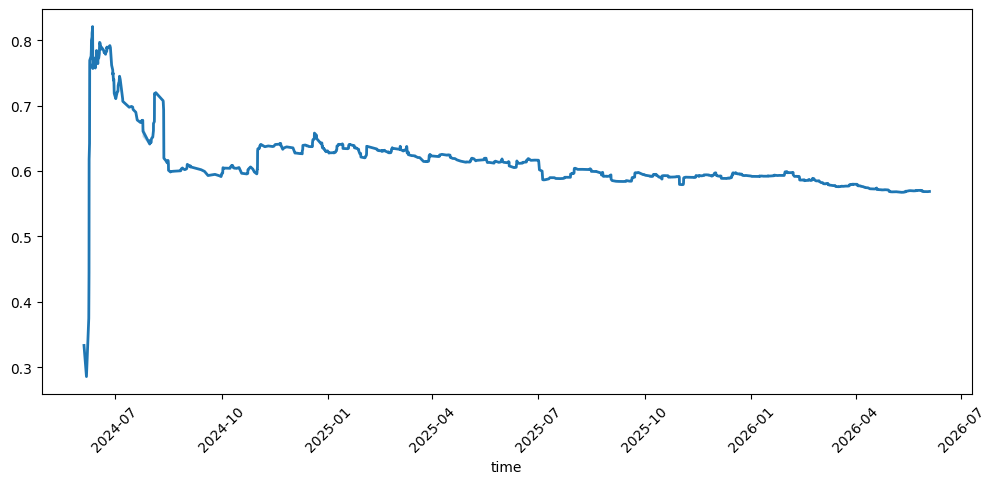

In [30]:
figsize = (12, 5)
plt.figure(figsize=figsize)

tmp = res[res["target"] == 1]

if len(tmp) > 0:
    tmp["ppv_npv_acc"] = tmp["target"].rolling(len(tmp), min_periods=1).count() / (tmp.index + 1)

    ax = sns.lineplot(x=tmp["time"], y=tmp["ppv_npv_acc"].values)
    ax.lines[0].set_linewidth(2)
    plt.xticks(rotation=45);

### Show model uncertainty on test data

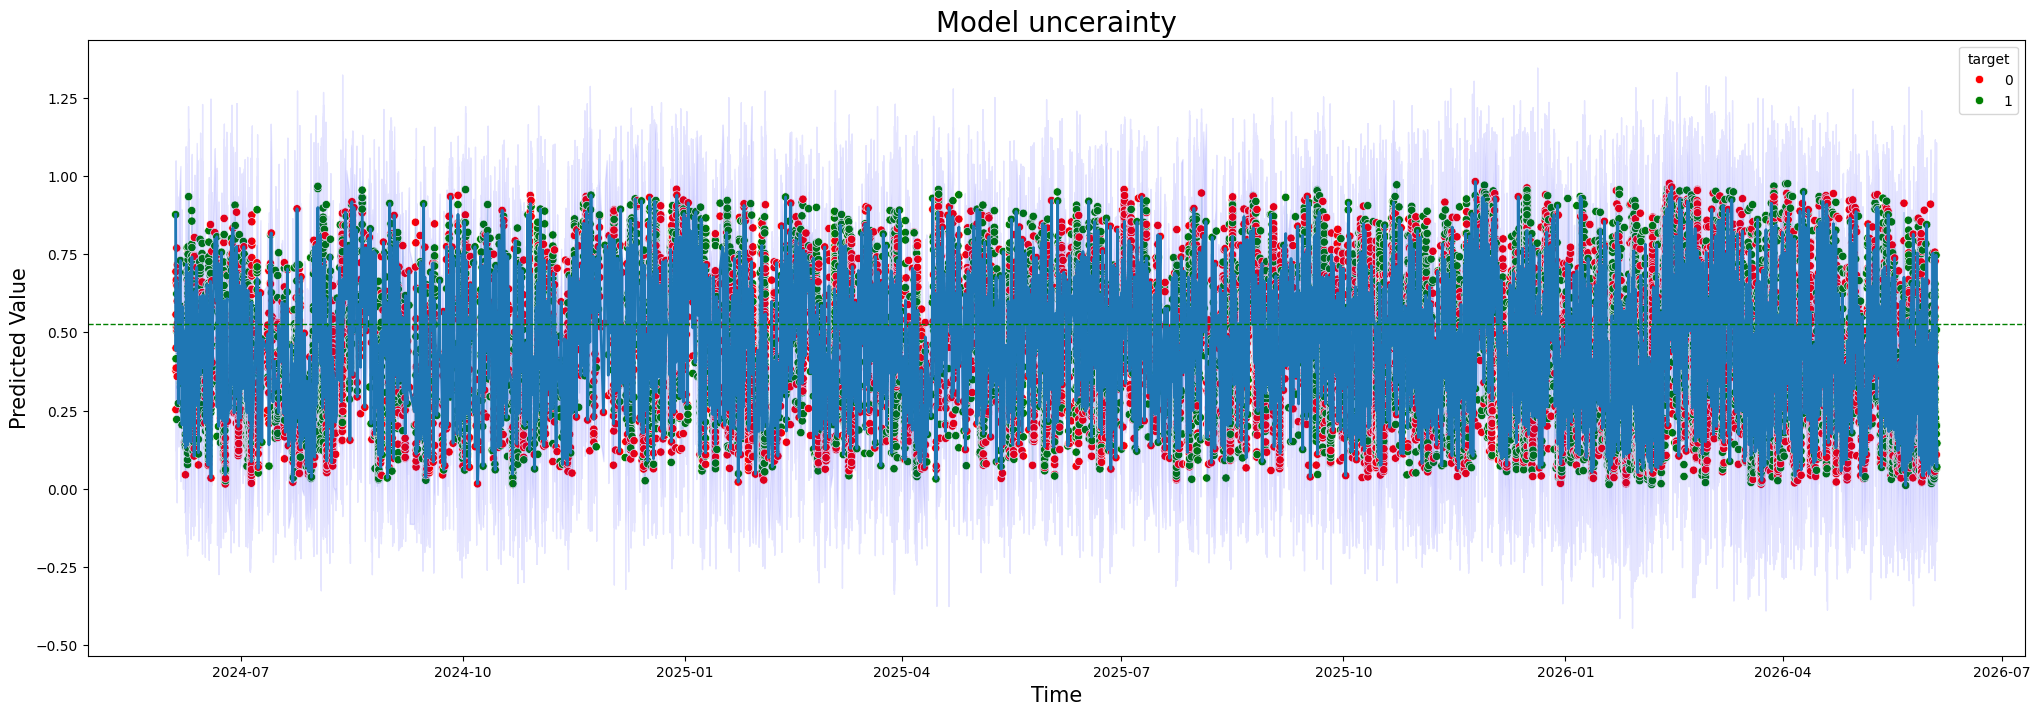

In [31]:
from utils.boosting_uncertainty import predict_with_uncertainty

mask = train_df["time"] >= test_date
features_ = train_df.loc[mask, features]
target_ = train_df.loc[mask, "target"]
color = target_.apply(lambda t: "green" if t == 1 else "red")
prediction_dict = predict_with_uncertainty(model, features_, k=20)

ticker = train_df.loc[mask, "ticker"]
time = train_df.loc[mask, "time"]

pred = prediction_dict.pred_virt
lcb = prediction_dict.lcb
ucb = prediction_dict.ucb

plt.figure(figsize=(25, 8))
plt.title("Model uncerainty", fontsize=20)
sns.lineplot(x=time, y=pred, linewidth=2)
plt.axhline(y=high_bound, color="green", linestyle="--", linewidth=1)
sns.scatterplot(x=time, y=pred, hue=target_, palette=["red", "green"])
plt.fill_between(time, lcb, ucb, color='b', alpha=.1)
plt.xlabel("Time", fontsize=15)
plt.ylabel("Predicted Value", fontsize=15);